<h1 align="center" id="top"><u>RL project</u></h1>
<h3 align="center"><u>Clément MOLLY-MITTON | Diane VERBECQ | Fanny BADOULES | Ghiles KEMICHE</u></h3>

# Table of Contents
***
1. [Import](#import)
2. [Testing](#testing)

## Import
***

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from rl_project.benchmark.benchmark import HighwayBenchmark
from rl_project.benchmark.typing import BenchmarkConfig
from rl_project.models.core.typing import ModelType
from rl_project.models.factory import load_model
from scripts.envs.factory import get_env_config
from scripts.envs.typing import EnvType
from scripts.utils.cache import CacheManager
from scripts.utils.display import display_episode

SEEDS = [1, 2, 3]

env_type = EnvType.BASELINE
env_id, env_config = get_env_config(env_type)
env_config["offscreen_rendering"] = True

benchmark = HighwayBenchmark(
    config=BenchmarkConfig(
        env_id=env_id,
        env_config=env_config,
    ),
    render_mode="rgb_array",
)
seed = 1
env = benchmark.make_env(seed=seed)

In [2]:
# ============================================================
# Paths
# ============================================================


def training_csv_path(
    base_dir: str | Path,
    model_type: ModelType,
    env_type: EnvType,
    seed: int,
) -> Path:
    base_dir = Path(base_dir)
    return (
        base_dir
        / "data"
        / "training"
        / model_type.value
        / env_type.value
        / f"seed_{seed}"
        / f"training_history_{model_type.value}_{env_type.value}_seed_{seed}.csv"
    )


def evaluation_csv_path(
    base_dir: str | Path,
    model_type: ModelType,
    env_type: EnvType,
    seed: int,
) -> Path:
    base_dir = Path(base_dir)
    return (
        base_dir
        / "data"
        / "evaluation"
        / model_type.value
        / env_type.value
        / f"seed_{seed}"
        / f"evaluation_history_{model_type.value}_{env_type.value}_seed_{seed}.csv"
    )


def get_model_path(
    base_dir: str | Path,
    model_type: ModelType,
    env_type: EnvType,
    seed: int,
) -> Path:
    base_dir = Path(base_dir)
    return (
        base_dir
        / "data"
        / "training"
        / model_type.value
        / env_type.value
        / f"seed_{seed}"
        / f"model_{model_type.value}_{env_type.value}_seed_{seed}_best.pt"
    )


# ============================================================
# Loading
# ============================================================


def load_training_histories(
    base_dir: str | Path,
    model_type: ModelType,
    env_type: EnvType,
    seeds: list[int] = SEEDS,
) -> dict[int, pd.DataFrame]:
    histories = {}

    for seed in seeds:
        path = training_csv_path(base_dir, model_type, env_type, seed)
        df = CacheManager.load(path).copy()
        df["train_seed"] = seed
        histories[seed] = df

    return histories


def load_evaluation_histories(
    base_dir: str | Path,
    model_type: ModelType,
    env_type: EnvType,
    seeds: list[int] = SEEDS,
) -> dict[int, pd.DataFrame]:
    histories = {}

    for seed in seeds:
        path = evaluation_csv_path(base_dir, model_type, env_type, seed)
        df = CacheManager.load(path).copy()
        df["train_seed"] = seed
        histories[seed] = df

    return histories


# ============================================================
# Helpers
# ============================================================


def smooth_series(series: pd.Series, window: int = 100) -> pd.Series:
    return series.rolling(window=window, min_periods=1).mean()


def downsample_df(df: pd.DataFrame, max_points: int = 1500) -> pd.DataFrame:
    """
    Réduit le nombre de points affichés pour éviter des graphes trop chargés.
    """
    if len(df) <= max_points:
        return df

    step = max(1, len(df) // max_points)
    return df.iloc[::step].copy()


def _build_smoothed_seed_mean(
    histories: dict[int, pd.DataFrame],
    metric: str,
    smooth_window: int,
    max_points: int,
) -> pd.DataFrame:
    """
    Construit un dataframe:
    - episode
    - seed_1
    - seed_2
    - seed_3
    - mean_across_seeds
    """
    merged = None

    for seed, df in histories.items():
        plot_df = downsample_df(df[["episode", metric]].copy(), max_points=max_points)
        plot_df[metric] = smooth_series(plot_df[metric], window=smooth_window)
        plot_df = plot_df.rename(columns={metric: f"seed_{seed}"})

        merged = plot_df if merged is None else merged.merge(plot_df, on="episode", how="outer")

    merged = merged.sort_values("episode")
    seed_cols = [c for c in merged.columns if c.startswith("seed_")]
    merged["mean_across_seeds"] = merged[seed_cols].mean(axis=1)

    return merged


# ============================================================
# Training aggregation
# ============================================================


def aggregate_training_by_episode(training_df: pd.DataFrame) -> pd.DataFrame:
    """
    Transforme le log step-by-step en métriques par épisode.

    Retourne un dataframe avec :
    - episode
    - total_reward
    - mean_reward
    - mean_speed
    - max_step
    - episode_length
    - crashed_any
    - offroad_any
    """
    agg = training_df.groupby("episode", as_index=False).agg(
        total_reward=("reward", "sum"),
        mean_reward=("reward", "mean"),
        mean_speed=("speed", "mean"),
        max_step=("step", "max"),
        episode_length=("step_in_episode", "max"),
        crashed_any=("crashed", "max"),
        offroad_any=("offroad", "max"),
    )

    # step_in_episode démarre souvent à 0, donc on ajoute 1
    agg["episode_length"] = agg["episode_length"] + 1

    # conversion bool -> int
    agg["crashed_any"] = agg["crashed_any"].astype(int)
    agg["offroad_any"] = agg["offroad_any"].astype(int)

    return agg


def build_training_episode_histories(
    training_histories: dict[int, pd.DataFrame],
) -> dict[int, pd.DataFrame]:
    return {seed: aggregate_training_by_episode(df) for seed, df in training_histories.items()}


# ============================================================
# Better training plots
# ============================================================


def plot_training_metric_by_seed_smoothed(
    training_episode_histories: dict[int, pd.DataFrame],
    metric: str,
    title: str | None = None,
    smooth_window: int = 100,
    show_raw: bool = True,
    raw_alpha: float = 0.10,
    max_points: int = 1500,
    figsize: tuple[int, int] = (11, 5),
) -> None:
    """
    Pour les métriques continues :
    - courbe brute légère
    - courbe lissée par seed
    - moyenne inter-seeds plus épaisse
    """
    plt.figure(figsize=figsize)

    for seed, df in training_episode_histories.items():
        if metric not in df.columns:
            continue

        plot_df = downsample_df(df, max_points=max_points)

        if show_raw:
            plt.plot(
                plot_df["episode"],
                plot_df[metric],
                alpha=raw_alpha,
                linewidth=0.8,
                label=f"seed {seed} raw",
            )

        smoothed = smooth_series(plot_df[metric], window=smooth_window)
        plt.plot(
            plot_df["episode"],
            smoothed,
            linewidth=2,
            label=f"seed {seed} smooth",
        )

    mean_df = _build_smoothed_seed_mean(
        histories=training_episode_histories,
        metric=metric,
        smooth_window=smooth_window,
        max_points=max_points,
    )

    plt.plot(
        mean_df["episode"],
        mean_df["mean_across_seeds"],
        linewidth=3,
        label="mean seeds",
    )

    plt.xlabel("episode")
    plt.ylabel(metric)
    plt.title(title or f"{metric} par épisode")
    plt.legend(ncol=2)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_training_binary_rate_by_seed(
    training_episode_histories: dict[int, pd.DataFrame],
    metric: str,
    title: str | None = None,
    smooth_window: int = 100,
    figsize: tuple[int, int] = (11, 5),
) -> None:
    """
    Pour les métriques binaires (crashed_any, offroad_any),
    on affiche un taux glissant au lieu du 0/1 brut.
    """
    plt.figure(figsize=figsize)

    for seed, df in training_episode_histories.items():
        if metric not in df.columns:
            continue

        rate = smooth_series(df[metric], window=smooth_window)
        plt.plot(
            df["episode"],
            rate,
            linewidth=2,
            label=f"seed {seed}",
        )

    mean_df = _build_smoothed_seed_mean(
        histories=training_episode_histories,
        metric=metric,
        smooth_window=smooth_window,
        max_points=10_000_000,
    )

    plt.plot(
        mean_df["episode"],
        mean_df["mean_across_seeds"],
        linewidth=3,
        label="mean seeds",
    )

    plt.ylim(-0.02, 1.02)
    plt.xlabel("episode")
    plt.ylabel(f"{metric}_rate")
    plt.title(title or f"{metric} rate")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()


def plot_all_training_graphs_for_model(
    base_dir: str | Path,
    model_type: ModelType,
    env_type: EnvType,
    seeds: list[int] = SEEDS,
    smooth_window: int = 100,
    show_raw: bool = False,
    max_points: int = 1500,
) -> dict[int, pd.DataFrame]:
    """
    Charge les trainings, agrège par épisode, puis affiche tous les graphes utiles
    avec une version beaucoup plus lisible.
    """
    raw_histories = load_training_histories(
        base_dir=base_dir,
        model_type=model_type,
        env_type=env_type,
        seeds=seeds,
    )

    episode_histories = build_training_episode_histories(raw_histories)

    continuous_metrics = [
        ("total_reward", "Training - total reward par épisode"),
        ("mean_reward", "Training - mean reward par épisode"),
        ("mean_speed", "Training - mean speed par épisode"),
        ("episode_length", "Training - longueur d'épisode"),
    ]

    binary_metrics = [
        ("crashed_any", "Training - crash rate glissant"),
        # ("offroad_any", "Training - offroad rate glissant"),
    ]

    for metric, title in continuous_metrics:
        plot_training_metric_by_seed_smoothed(
            training_episode_histories=episode_histories,
            metric=metric,
            title=f"{model_type.value} | {env_type.value} | {title}",
            smooth_window=smooth_window,
            show_raw=show_raw,
            max_points=max_points,
        )

    for metric, title in binary_metrics:
        plot_training_binary_rate_by_seed(
            training_episode_histories=episode_histories,
            metric=metric,
            title=f"{model_type.value} | {env_type.value} | {title}",
            smooth_window=smooth_window,
        )

    return episode_histories


# ============================================================
# Evaluation merge + stats
# ============================================================


def merge_evaluation_histories(
    evaluation_histories: dict[int, pd.DataFrame],
) -> pd.DataFrame:
    """
    Concatène les dataframes d'évaluation des 3 seeds.
    """
    merged = pd.concat(evaluation_histories.values(), ignore_index=True).copy()

    for col in ["crashed", "offroad"]:
        if col in merged.columns:
            merged[col] = merged[col].astype(int)

    return merged


def evaluation_stats_by_episode(merged_eval_df: pd.DataFrame) -> pd.DataFrame:
    """
    Stats par épisode d'évaluation :
    moyenne / std / min / max sur les seeds d'entraînement.
    """
    numeric_cols = ["reward", "length", "mean_speed", "crashed", "offroad"]
    numeric_cols = [c for c in numeric_cols if c in merged_eval_df.columns]

    stats = (
        merged_eval_df.groupby("episode")[numeric_cols]
        .agg(["mean", "std", "min", "max"])
        .reset_index()
    )

    stats.columns = [
        "episode" if col[0] == "episode" else f"{col[0]}_{col[1]}" for col in stats.columns
    ]
    return stats


def evaluation_global_stats(merged_eval_df: pd.DataFrame) -> pd.DataFrame:
    """
    Stats globales sur l'ensemble des épisodes d'évaluation
    et sur les 3 seeds regroupées.
    """
    stats = {}

    if "reward" in merged_eval_df.columns:
        stats["reward_mean"] = merged_eval_df["reward"].mean()
        stats["reward_std"] = merged_eval_df["reward"].std()
        stats["reward_min"] = merged_eval_df["reward"].min()
        stats["reward_max"] = merged_eval_df["reward"].max()

    if "length" in merged_eval_df.columns:
        stats["length_mean"] = merged_eval_df["length"].mean()
        stats["length_std"] = merged_eval_df["length"].std()
        stats["length_min"] = merged_eval_df["length"].min()
        stats["length_max"] = merged_eval_df["length"].max()

    if "mean_speed" in merged_eval_df.columns:
        stats["mean_speed_mean"] = merged_eval_df["mean_speed"].mean()
        stats["mean_speed_std"] = merged_eval_df["mean_speed"].std()
        stats["mean_speed_min"] = merged_eval_df["mean_speed"].min()
        stats["mean_speed_max"] = merged_eval_df["mean_speed"].max()

    if "crashed" in merged_eval_df.columns:
        stats["crash_rate"] = merged_eval_df["crashed"].mean()

    if "offroad" in merged_eval_df.columns:
        stats["offroad_rate"] = merged_eval_df["offroad"].mean()

    stats["n_rows"] = len(merged_eval_df)
    stats["n_train_seeds"] = merged_eval_df["train_seed"].nunique()

    return pd.DataFrame([stats])


def evaluation_stats_by_train_seed(merged_eval_df: pd.DataFrame) -> pd.DataFrame:
    """
    Tableau par seed d'entraînement.
    """
    rows = []

    for seed, df_seed in merged_eval_df.groupby("train_seed"):
        row = {
            "train_seed": seed,
            "n_rows": len(df_seed),
        }

        if "reward" in df_seed.columns:
            row["reward_mean"] = df_seed["reward"].mean()
            row["reward_std"] = df_seed["reward"].std()
            row["reward_min"] = df_seed["reward"].min()
            row["reward_max"] = df_seed["reward"].max()

        if "length" in df_seed.columns:
            row["length_mean"] = df_seed["length"].mean()
            row["length_std"] = df_seed["length"].std()
            row["length_min"] = df_seed["length"].min()
            row["length_max"] = df_seed["length"].max()

        if "mean_speed" in df_seed.columns:
            row["mean_speed_mean"] = df_seed["mean_speed"].mean()
            row["mean_speed_std"] = df_seed["mean_speed"].std()
            row["mean_speed_min"] = df_seed["mean_speed"].min()
            row["mean_speed_max"] = df_seed["mean_speed"].max()

        if "crashed" in df_seed.columns:
            row["crash_rate"] = df_seed["crashed"].mean()

        if "offroad" in df_seed.columns:
            row["offroad_rate"] = df_seed["offroad"].mean()

        rows.append(row)

    return pd.DataFrame(rows).sort_values("train_seed").reset_index(drop=True)


def summarize_evaluation_for_model(
    base_dir: str | Path,
    model_type: ModelType,
    env_type: EnvType,
    seeds: list[int] = SEEDS,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Retourne :
    - merged_eval_df
    - per_episode_stats
    - global_stats
    - per_seed_stats
    """
    eval_histories = load_evaluation_histories(
        base_dir=base_dir,
        model_type=model_type,
        env_type=env_type,
        seeds=seeds,
    )

    merged_eval_df = merge_evaluation_histories(eval_histories)
    per_episode_stats = evaluation_stats_by_episode(merged_eval_df)
    global_stats = evaluation_global_stats(merged_eval_df)
    per_seed_stats = evaluation_stats_by_train_seed(merged_eval_df)

    return merged_eval_df, per_episode_stats, global_stats, per_seed_stats


# ============================================================
# Evaluation tables only
# ============================================================


def display_evaluation_tables(
    base_dir: str | Path,
    model_type: ModelType,
    env_type: EnvType,
    seeds: list[int] = SEEDS,
    round_digits: int = 4,
) -> tuple[pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Affiche uniquement les tableaux d'évaluation.
    """
    merged_eval_df, per_episode_stats, global_stats, per_seed_stats = (
        summarize_evaluation_for_model(
            base_dir=base_dir,
            model_type=model_type,
            env_type=env_type,
            seeds=seeds,
        )
    )

    print(f"\n=== EVALUATION GLOBAL STATS | {model_type.value} | {env_type.value} ===")
    print(global_stats.round(round_digits).to_string(index=False))

    print(f"\n=== EVALUATION PER TRAIN SEED | {model_type.value} | {env_type.value} ===")
    print(per_seed_stats.round(round_digits).to_string(index=False))

    # print(f"\n=== EVALUATION PER EPISODE STATS | {model_type.value} | {env_type.value} ===")
    # print(per_episode_stats.round(round_digits).to_string(index=False))

    return merged_eval_df, per_episode_stats, global_stats, per_seed_stats


# ============================================================
# Main convenience function
# ============================================================


def display_training_and_evaluation(
    base_dir: str | Path,
    model_type: ModelType,
    env_type: EnvType,
    seeds: list[int] = SEEDS,
    smooth_window: int = 100,
    show_raw: bool = False,
    max_points: int = 1500,
    round_digits: int = 4,
) -> tuple[dict[int, pd.DataFrame], pd.DataFrame, pd.DataFrame, pd.DataFrame, pd.DataFrame]:
    """
    Fait tout :
    - graphes training
    - tableaux evaluation

    Retourne :
    - training_episode_histories
    - merged_eval_df
    - per_episode_stats
    - global_stats
    - per_seed_stats
    """
    training_episode_histories = plot_all_training_graphs_for_model(
        base_dir=base_dir,
        model_type=model_type,
        env_type=env_type,
        seeds=seeds,
        smooth_window=smooth_window,
        show_raw=show_raw,
        max_points=max_points,
    )

    merged_eval_df, per_episode_stats, global_stats, per_seed_stats = display_evaluation_tables(
        base_dir=base_dir,
        model_type=model_type,
        env_type=env_type,
        seeds=seeds,
        round_digits=round_digits,
    )

    return (
        training_episode_histories,
        merged_eval_df,
        per_episode_stats,
        global_stats,
        per_seed_stats,
    )

## DQN
***

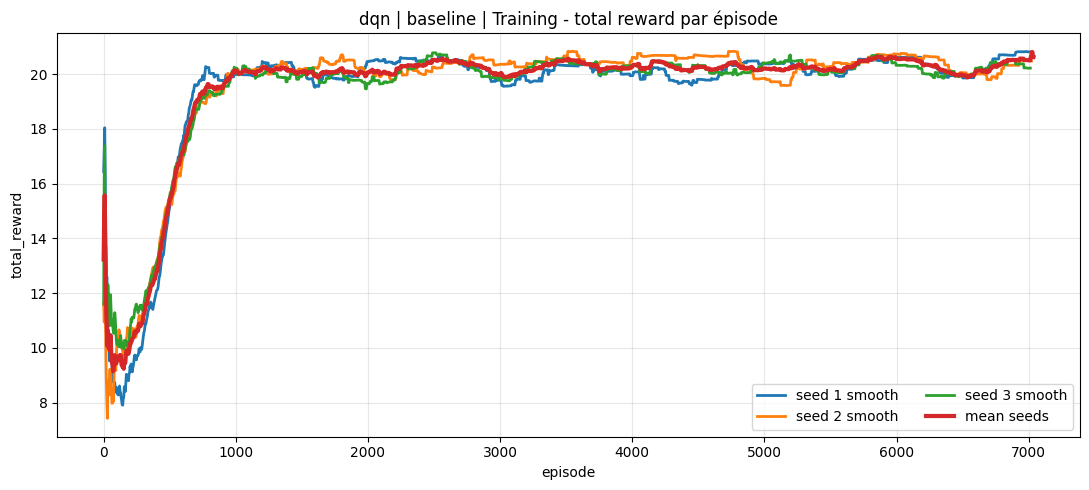

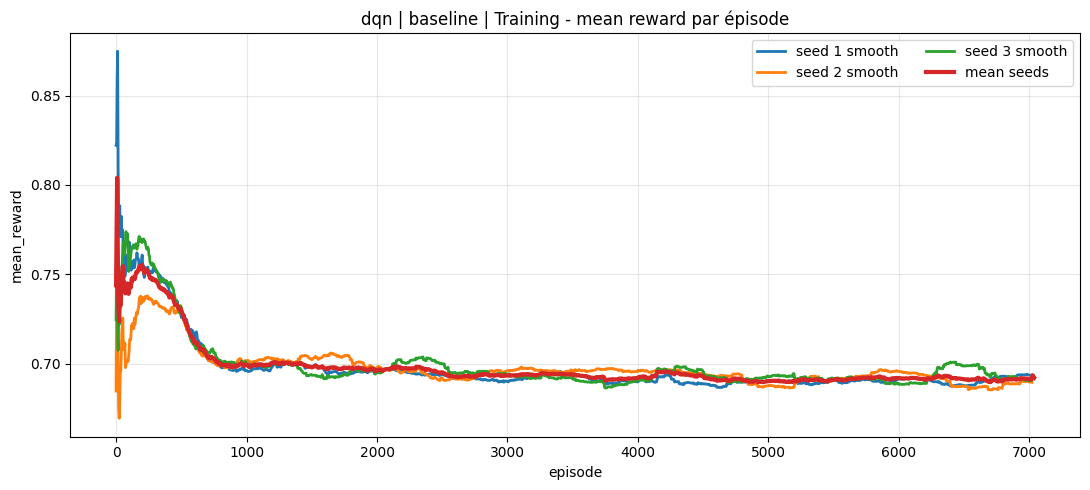

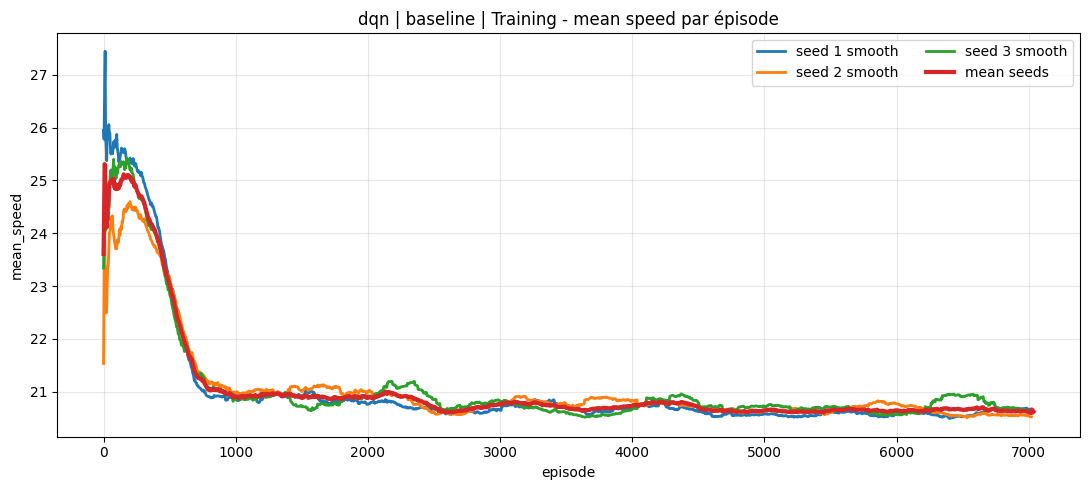

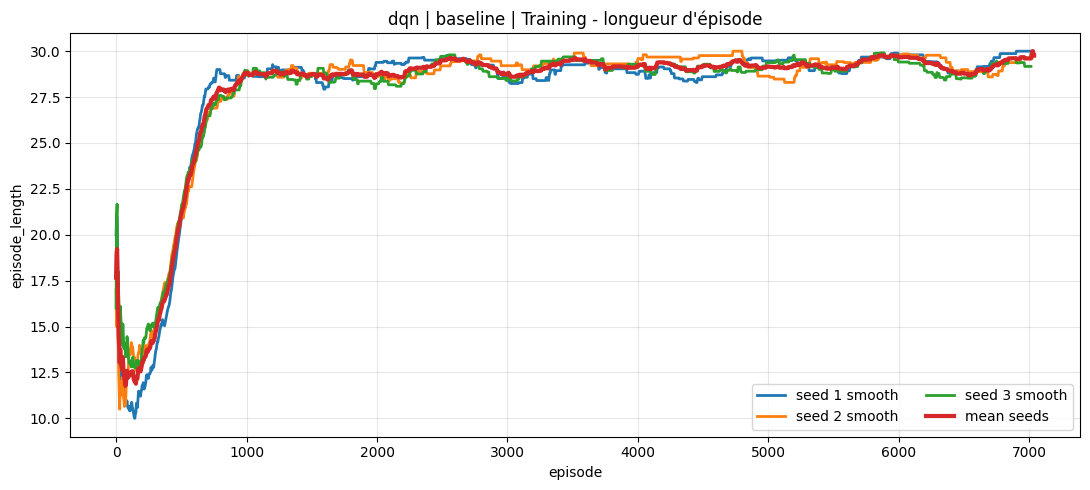

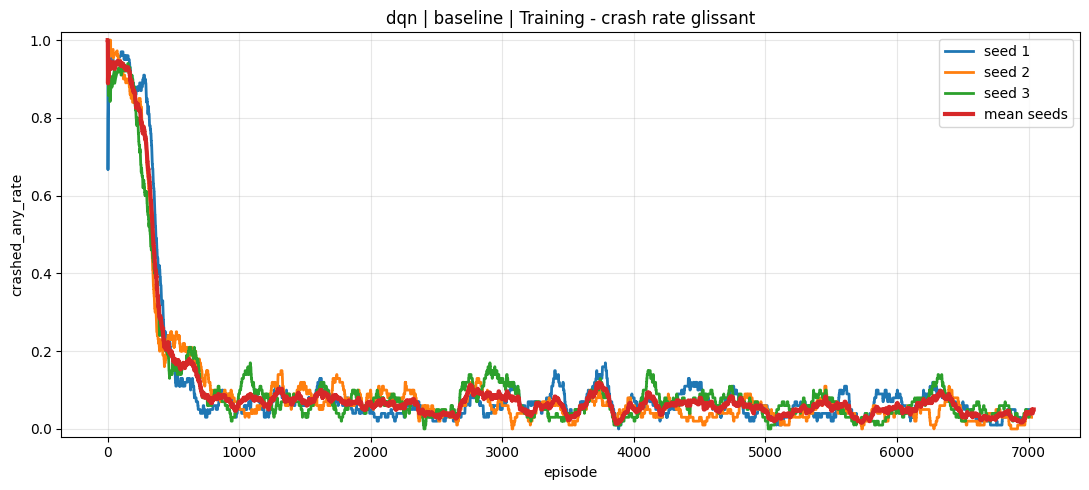

In [3]:
training_episode_histories = plot_all_training_graphs_for_model(
    base_dir=Path.cwd().parents[2],
    model_type=ModelType.DQN,
    env_type=EnvType.BASELINE,
    seeds=SEEDS,
)

In [4]:
merged_eval_df, per_episode_stats, global_stats, per_seed_stats = display_evaluation_tables(
    base_dir=Path.cwd().parents[2],
    model_type=ModelType.DQN,
    env_type=EnvType.BASELINE,
    seeds=SEEDS,
    round_digits=4,
)


=== EVALUATION GLOBAL STATS | dqn | baseline ===
 reward_mean  reward_std  reward_min  reward_max  length_mean  length_std  length_min  length_max  mean_speed_mean  mean_speed_std  mean_speed_min  mean_speed_max  crash_rate  offroad_rate  n_rows  n_train_seeds
     20.4944      1.7318      8.1818     23.4409      29.5867       2.309          13          30          20.6253          0.5584         19.7239          23.299        0.04           0.0     150              3

=== EVALUATION PER TRAIN SEED | dqn | baseline ===
 train_seed  n_rows  reward_mean  reward_std  reward_min  reward_max  length_mean  length_std  length_min  length_max  mean_speed_mean  mean_speed_std  mean_speed_min  mean_speed_max  crash_rate  offroad_rate
          1      50      20.7415      0.7632     16.3569     22.4010        29.86      0.9899          23          30          20.7054          0.6060         20.0344         22.5344        0.02           0.0
          2      50      20.3965      1.5436     11.7616

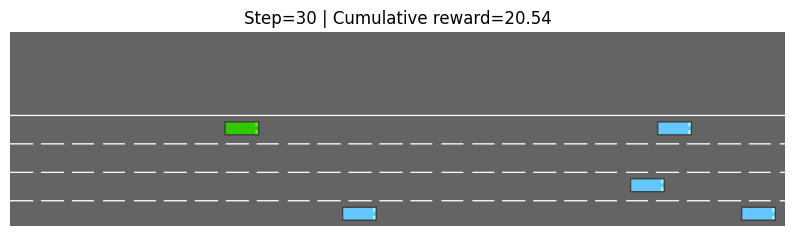

{'episode_reward': 20.53988102505304,
 'episode_length': 30,
 'crashed': False,
 'offroad': False,
 'mean_speed': 20.201018335075148}

In [5]:
env.reset(seed=seed)

model_type = ModelType.DQN
model_path = get_model_path(Path.cwd().parents[2], model_type, EnvType.BASELINE, seed=1)
model = load_model(model_type, model_path)

stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)
stats

## SB3
***

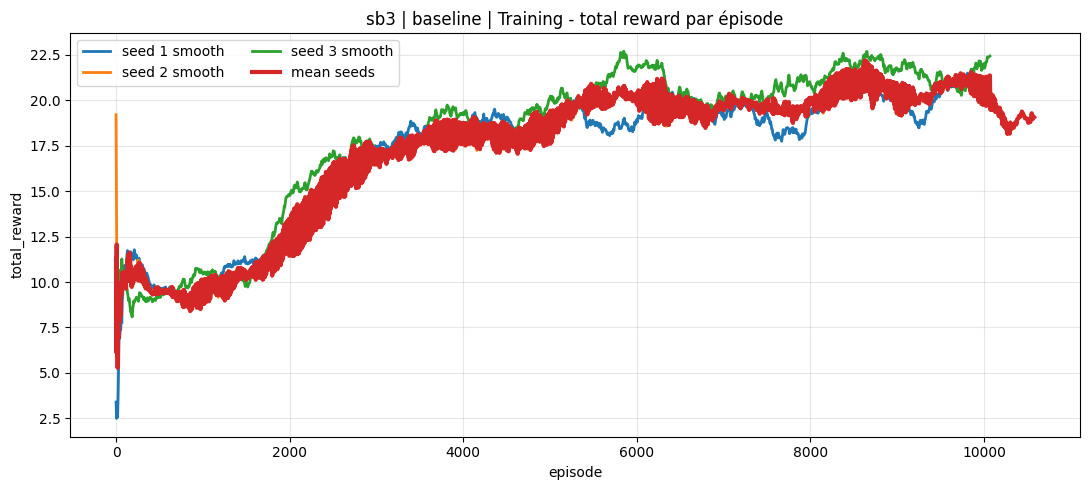

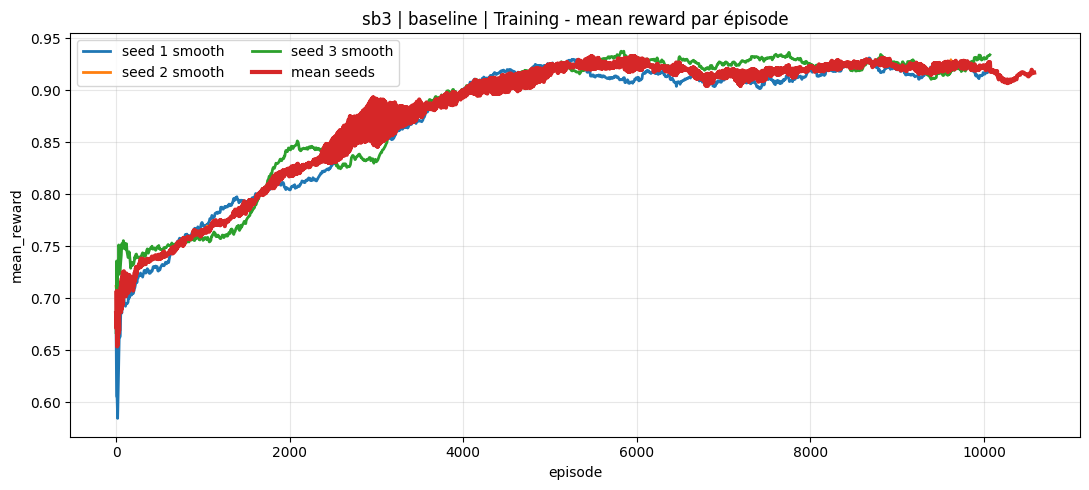

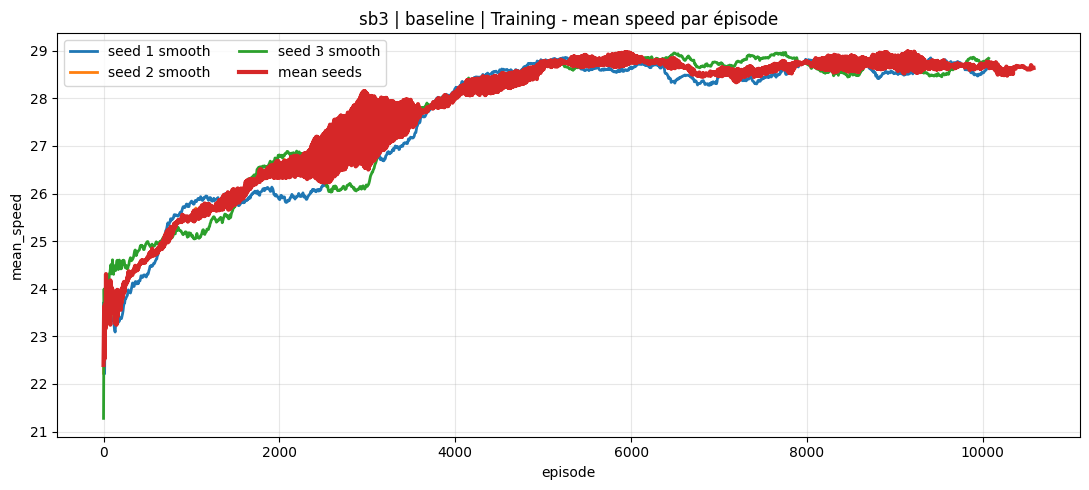

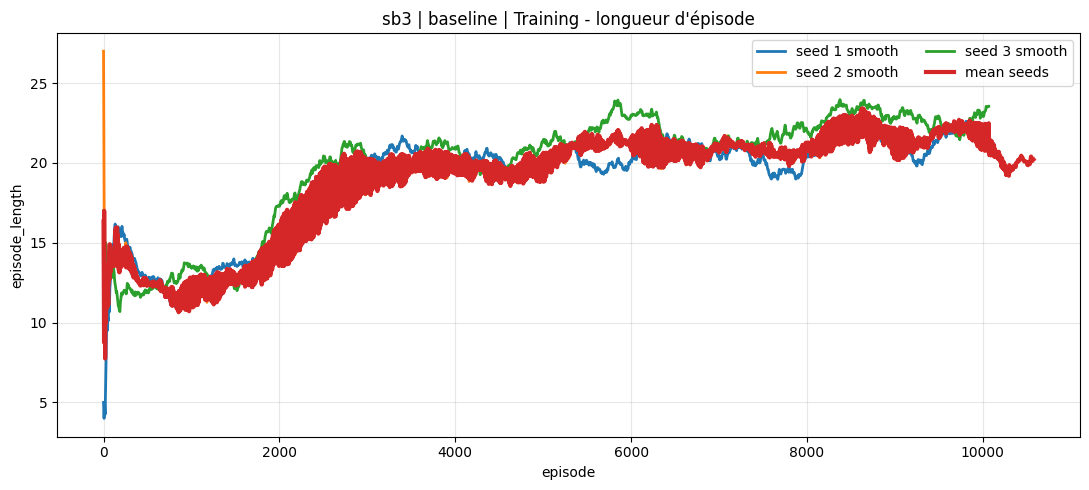

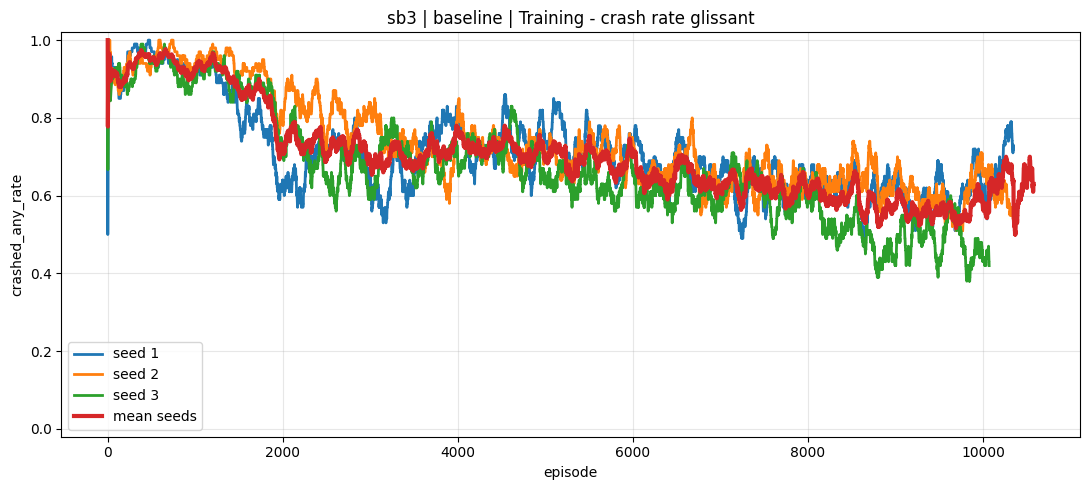

In [6]:
training_episode_histories = plot_all_training_graphs_for_model(
    base_dir=Path.cwd().parents[2],
    model_type=ModelType.SB3,
    env_type=EnvType.BASELINE,
    seeds=SEEDS,
)

In [7]:
merged_eval_df, per_episode_stats, global_stats, per_seed_stats = display_evaluation_tables(
    base_dir=Path.cwd().parents[2],
    model_type=ModelType.SB3,
    env_type=EnvType.BASELINE,
    seeds=SEEDS,
    round_digits=4,
)


=== EVALUATION GLOBAL STATS | sb3 | baseline ===
 reward_mean  reward_std  reward_min  reward_max  length_mean  length_std  length_min  length_max  mean_speed_mean  mean_speed_std  mean_speed_min  mean_speed_max  crash_rate  offroad_rate  n_rows  n_train_seeds
     22.5759      8.8426      0.9851     29.9516        23.42      8.5627           2          30          29.1113          1.1507         23.1677         29.9656        0.48           0.0     150              3

=== EVALUATION PER TRAIN SEED | sb3 | baseline ===
 train_seed  n_rows  reward_mean  reward_std  reward_min  reward_max  length_mean  length_std  length_min  length_max  mean_speed_mean  mean_speed_std  mean_speed_min  mean_speed_max  crash_rate  offroad_rate
          1      50      21.1635      9.2228      1.9584     29.9458        22.14      8.9511           3          30          28.8462          1.2133         24.6691         29.9656        0.52           0.0
          2      50      22.3228      8.9440      2.9592

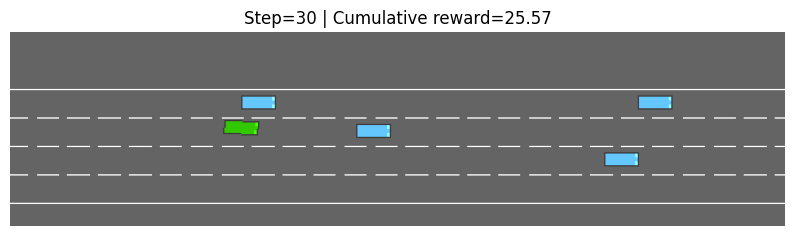

{'episode_reward': 25.57118264144445,
 'episode_length': 30,
 'crashed': False,
 'offroad': False,
 'mean_speed': 26.298981689907887}

In [8]:
env.reset(seed=seed)

model_type = ModelType.SB3
model_path = get_model_path(Path.cwd().parents[2], model_type, EnvType.BASELINE, seed=1)
model = load_model(model_type, model_path)

stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)
stats

### Double DQN
***

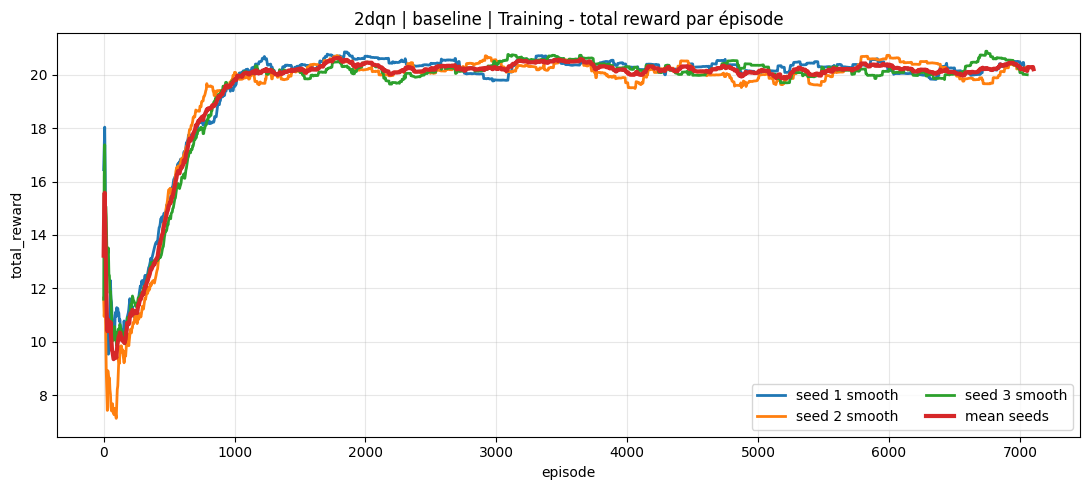

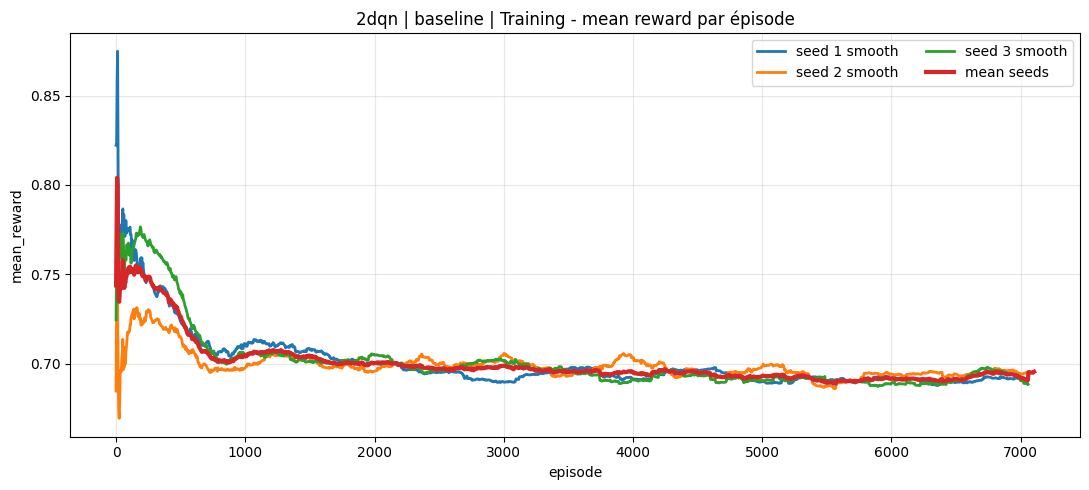

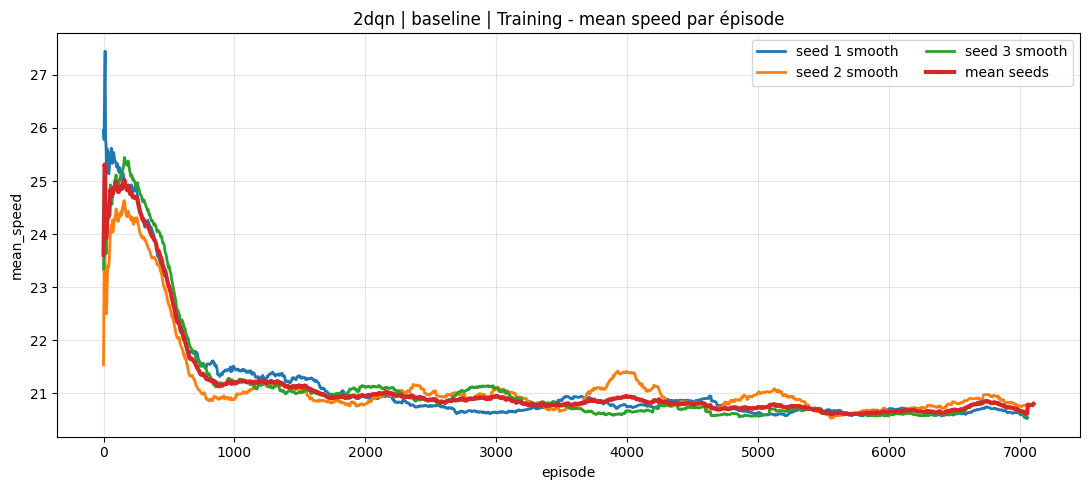

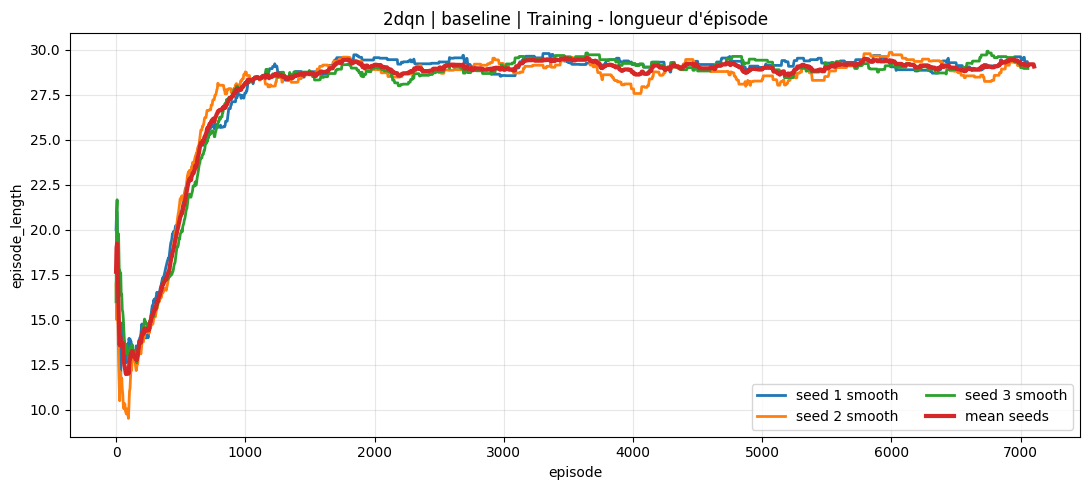

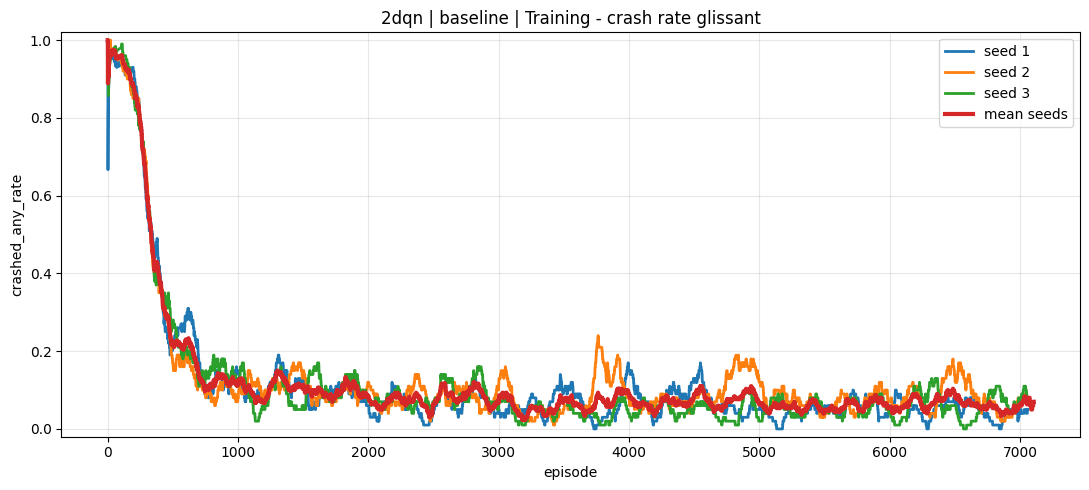

In [9]:
training_episode_histories = plot_all_training_graphs_for_model(
    base_dir=Path.cwd().parents[2],
    model_type=ModelType.DOUBLE_DQN,
    env_type=EnvType.BASELINE,
    seeds=SEEDS,
)

In [10]:
merged_eval_df, per_episode_stats, global_stats, per_seed_stats = display_evaluation_tables(
    base_dir=Path.cwd().parents[2],
    model_type=ModelType.DOUBLE_DQN,
    env_type=EnvType.BASELINE,
    seeds=SEEDS,
    round_digits=4,
)


=== EVALUATION GLOBAL STATS | 2dqn | baseline ===
 reward_mean  reward_std  reward_min  reward_max  length_mean  length_std  length_min  length_max  mean_speed_mean  mean_speed_std  mean_speed_min  mean_speed_max  crash_rate  offroad_rate  n_rows  n_train_seeds
     20.7552      0.2557     20.4545     22.1578         30.0         0.0          30          30          20.5818          0.4137         20.0344         22.3677         0.0           0.0     150              3

=== EVALUATION PER TRAIN SEED | 2dqn | baseline ===
 train_seed  n_rows  reward_mean  reward_std  reward_min  reward_max  length_mean  length_std  length_min  length_max  mean_speed_mean  mean_speed_std  mean_speed_min  mean_speed_max  crash_rate  offroad_rate
          1      50      20.7322      0.2087     20.4545     21.3447         30.0         0.0          30          30          20.5498          0.3734         20.0344         21.5344         0.0           0.0
          2      50      20.7973      0.2732     20.45

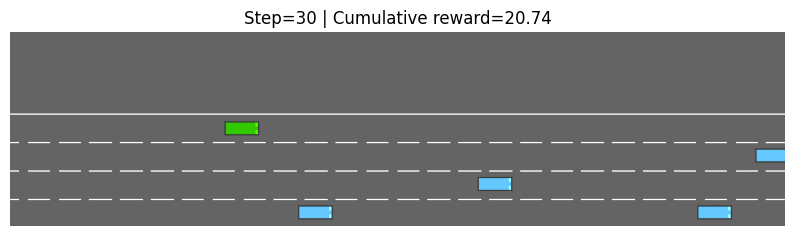

{'episode_reward': 20.742277331094943,
 'episode_length': 30,
 'crashed': False,
 'offroad': False,
 'mean_speed': 20.534209534596833}

In [11]:
env.reset(seed=seed)

model_type = ModelType.DOUBLE_DQN
model_path = get_model_path(Path.cwd().parents[2], model_type, EnvType.BASELINE, seed=1)
model = load_model(model_type, model_path)

stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)
stats

## Extensions 
***

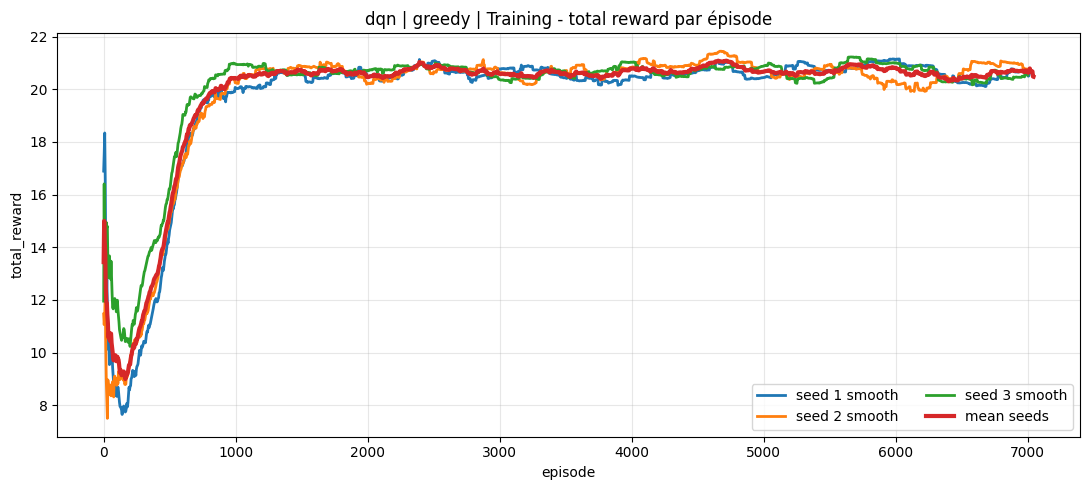

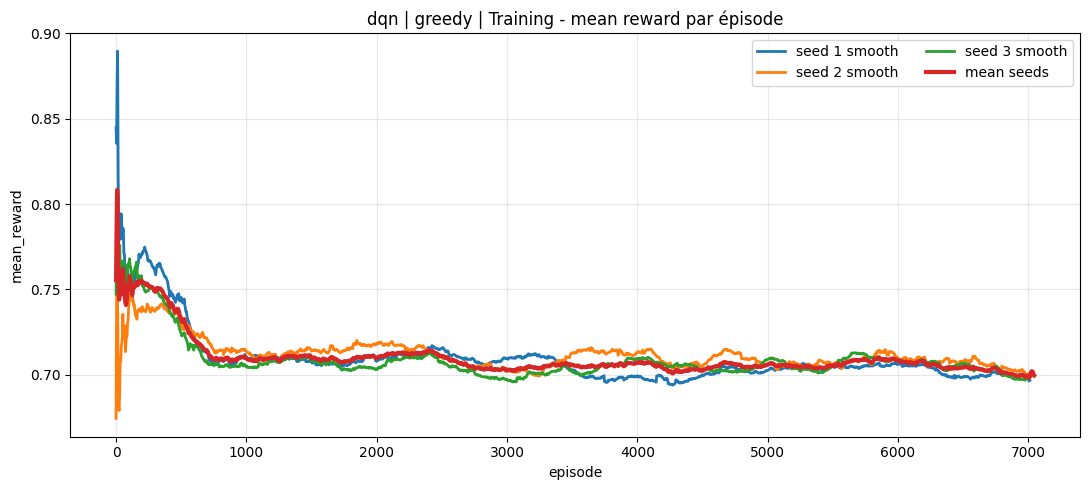

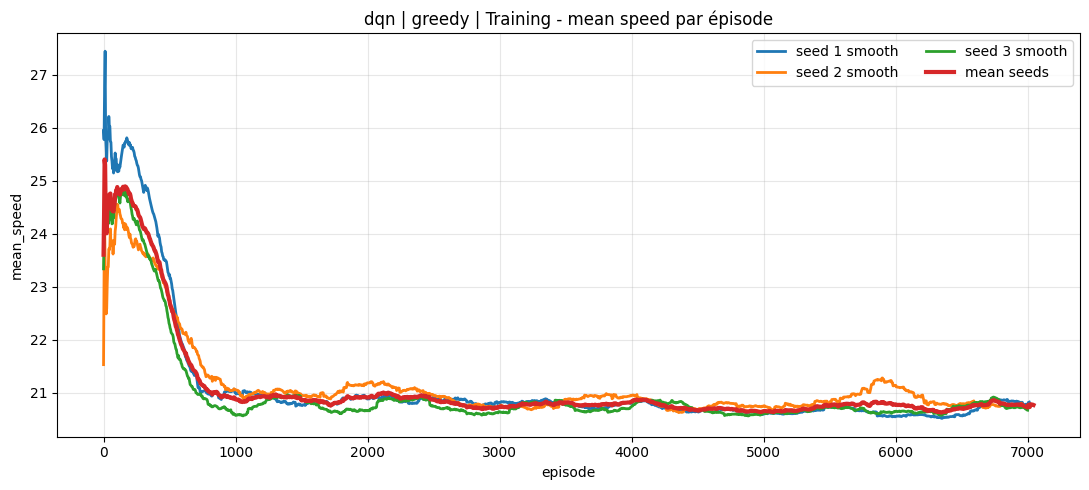

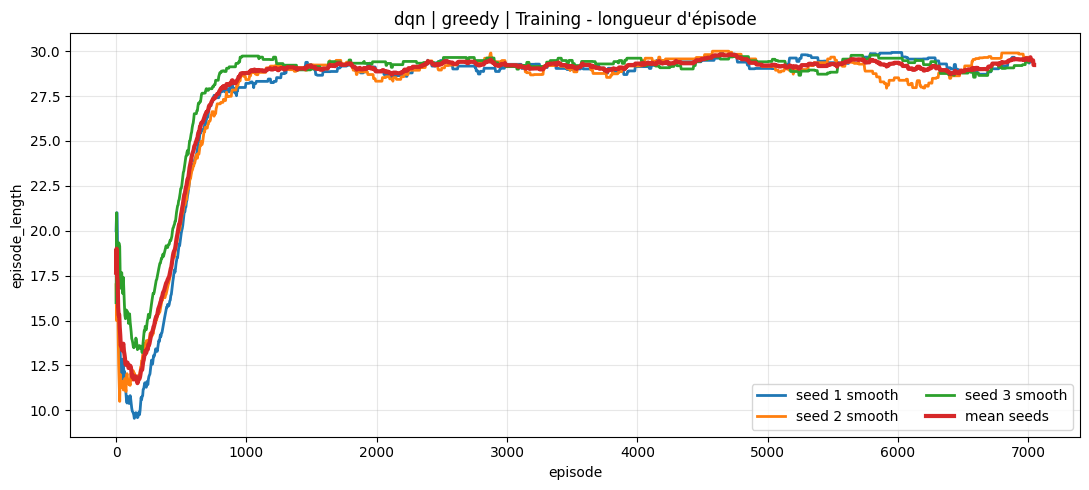

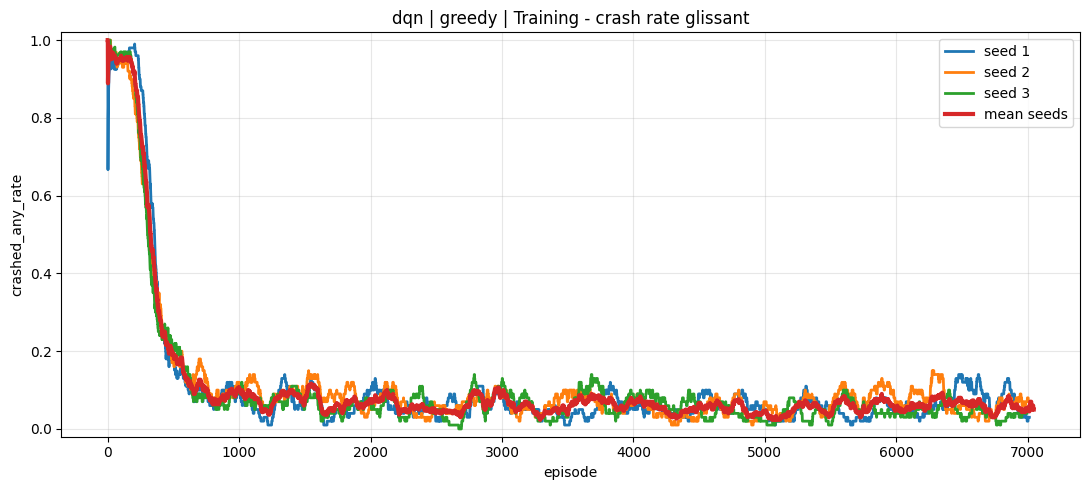

In [12]:
training_episode_histories = plot_all_training_graphs_for_model(
    base_dir=Path.cwd().parents[2],
    model_type=ModelType.DQN,
    env_type=EnvType.GREEDY,
    seeds=SEEDS,
)

In [13]:
merged_eval_df, per_episode_stats, global_stats, per_seed_stats = display_evaluation_tables(
    base_dir=Path.cwd().parents[2],
    model_type=ModelType.DQN,
    env_type=EnvType.GREEDY,
    seeds=SEEDS,
    round_digits=4,
)


=== EVALUATION GLOBAL STATS | dqn | greedy ===
 reward_mean  reward_std  reward_min  reward_max  length_mean  length_std  length_min  length_max  mean_speed_mean  mean_speed_std  mean_speed_min  mean_speed_max  crash_rate  offroad_rate  n_rows  n_train_seeds
     20.5549      1.8344      3.4091     23.2657      29.6133      2.4897           6          30          20.7045          0.5115          18.399         23.3667      0.0333           0.0     150              3

=== EVALUATION PER TRAIN SEED | dqn | greedy ===
 train_seed  n_rows  reward_mean  reward_std  reward_min  reward_max  length_mean  length_std  length_min  length_max  mean_speed_mean  mean_speed_std  mean_speed_min  mean_speed_max  crash_rate  offroad_rate
          1      50      20.7611      0.2680     20.4545     21.9307        30.00      0.0000          30          30          20.6014          0.4529         20.0344         22.1725        0.00           0.0
          2      50      20.8094      0.6528     17.2819    

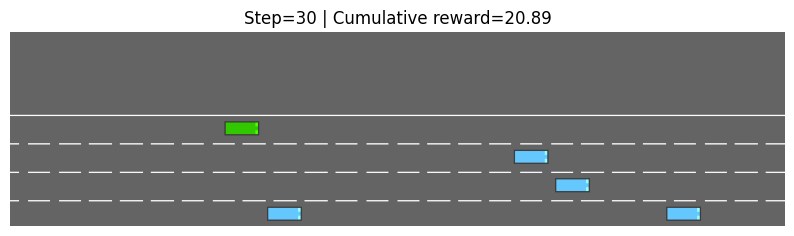

{'episode_reward': 20.886238081785933,
 'episode_length': 30,
 'crashed': False,
 'offroad': False,
 'mean_speed': 20.53435166840848}

In [14]:
env.reset(seed=seed)

model_type = ModelType.DQN
model_path = get_model_path(Path.cwd().parents[2], model_type, EnvType.GREEDY, seed=1)
model = load_model(model_type, model_path)

stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)
stats

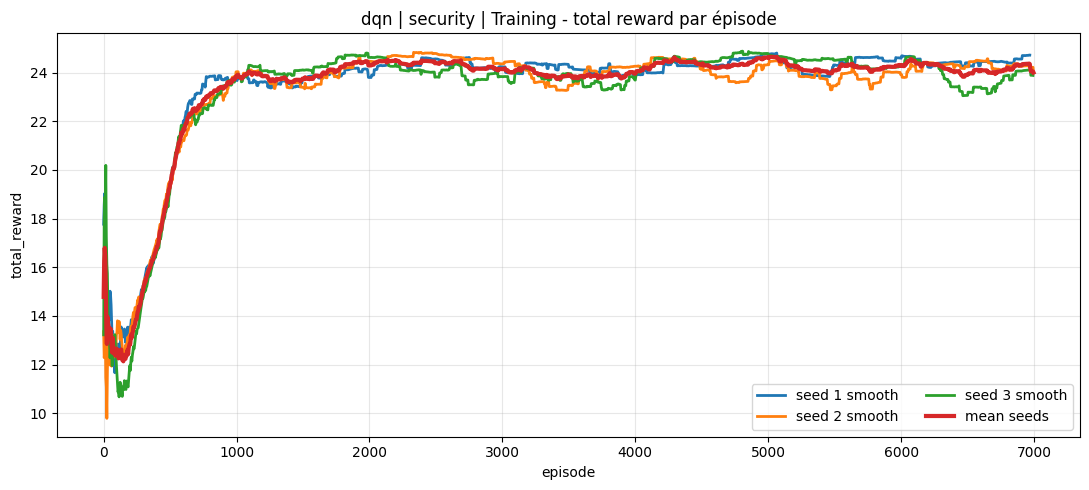

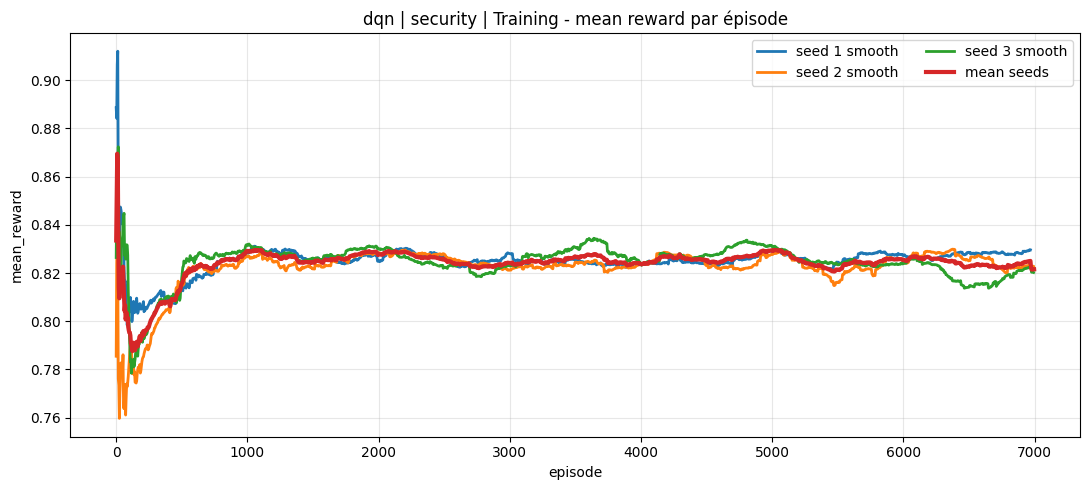

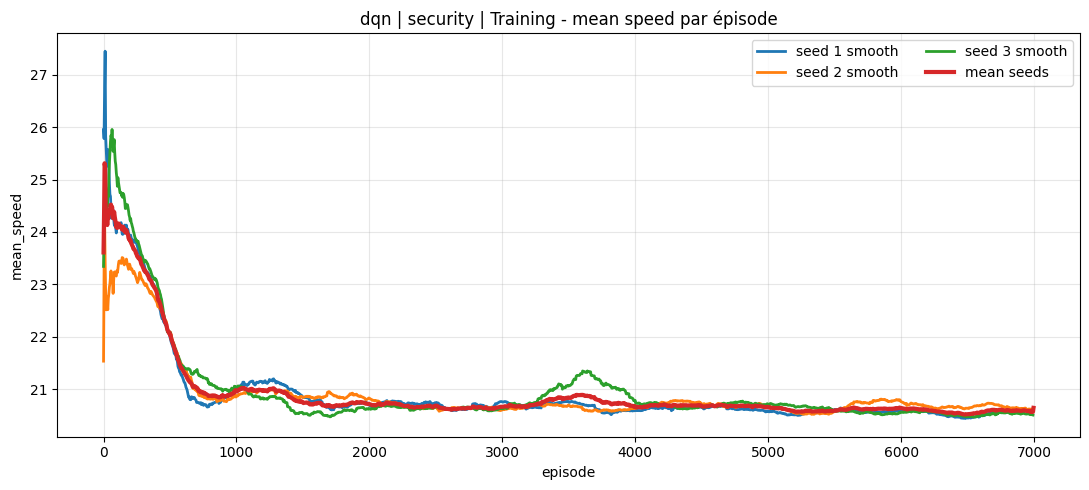

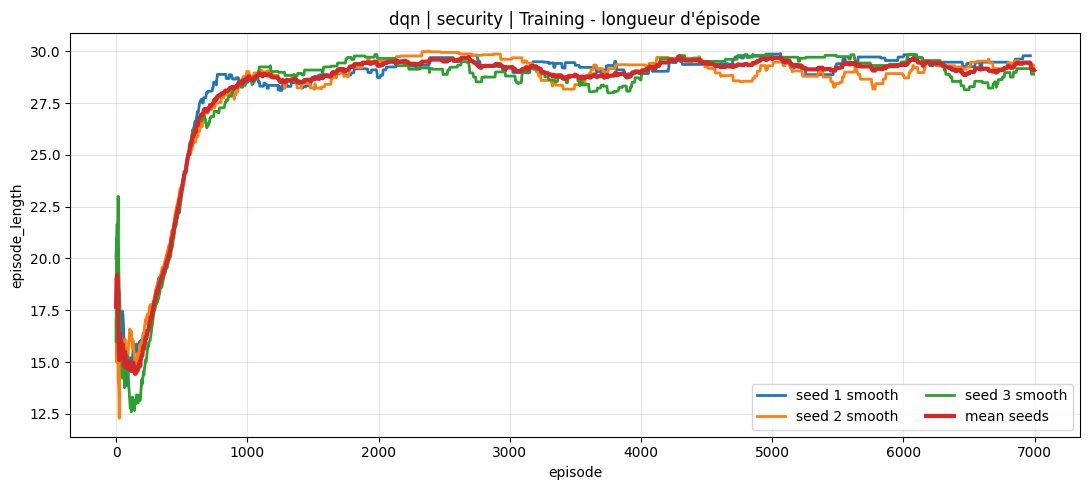

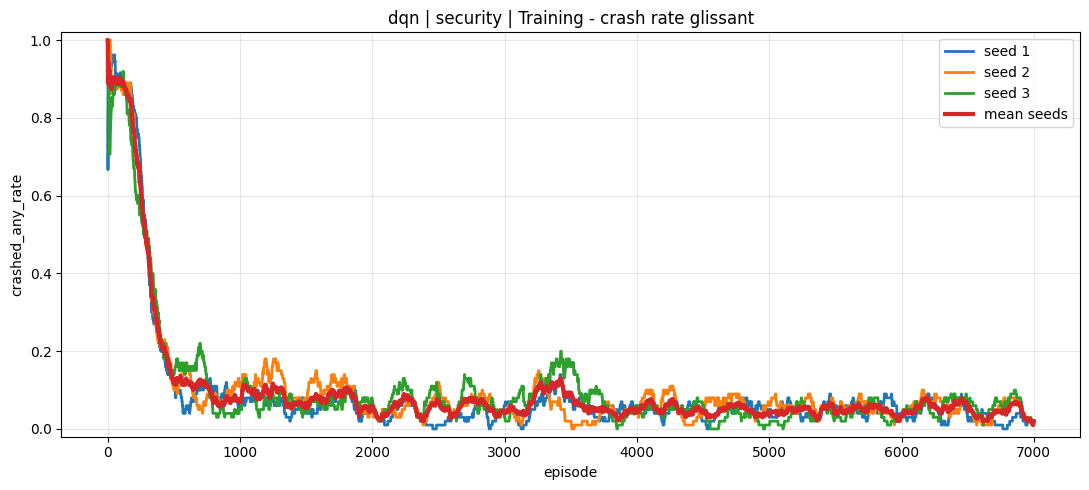

In [15]:
training_episode_histories = plot_all_training_graphs_for_model(
    base_dir=Path.cwd().parents[2],
    model_type=ModelType.DQN,
    env_type=EnvType.SECURITY,
    seeds=SEEDS,
)

In [16]:
merged_eval_df, per_episode_stats, global_stats, per_seed_stats = display_evaluation_tables(
    base_dir=Path.cwd().parents[2],
    model_type=ModelType.DQN,
    env_type=EnvType.SECURITY,
    seeds=SEEDS,
    round_digits=4,
)


=== EVALUATION GLOBAL STATS | dqn | security ===
 reward_mean  reward_std  reward_min  reward_max  length_mean  length_std  length_min  length_max  mean_speed_mean  mean_speed_std  mean_speed_min  mean_speed_max  crash_rate  offroad_rate  n_rows  n_train_seeds
     20.6674      1.0577      8.2672      22.442      29.8867       1.388          13          30          20.5517          0.4375         20.0344         22.8333      0.0067           0.0     150              3

=== EVALUATION PER TRAIN SEED | dqn | security ===
 train_seed  n_rows  reward_mean  reward_std  reward_min  reward_max  length_mean  length_std  length_min  length_max  mean_speed_mean  mean_speed_std  mean_speed_min  mean_speed_max  crash_rate  offroad_rate
          1      50      20.6749      0.2021     20.4545     21.3428        30.00      0.0000          30          30          20.4469          0.3674         20.0344         21.5010        0.00           0.0
          2      50      20.6349      1.8253      8.2672

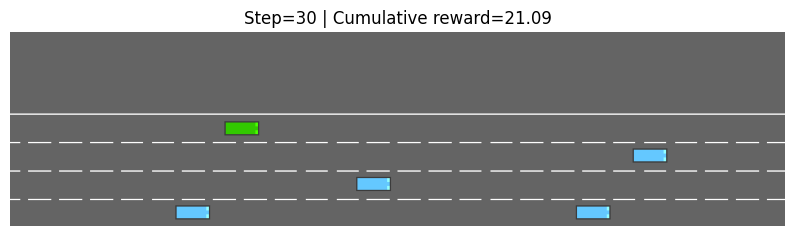

{'episode_reward': 21.09021623194046,
 'episode_length': 30,
 'crashed': False,
 'offroad': False,
 'mean_speed': 21.034351668407854}

In [17]:
env.reset(seed=seed)

model_type = ModelType.DQN
model_path = get_model_path(Path.cwd().parents[2], model_type, EnvType.SECURITY, seed=1)
model = load_model(model_type, model_path)

stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)
stats

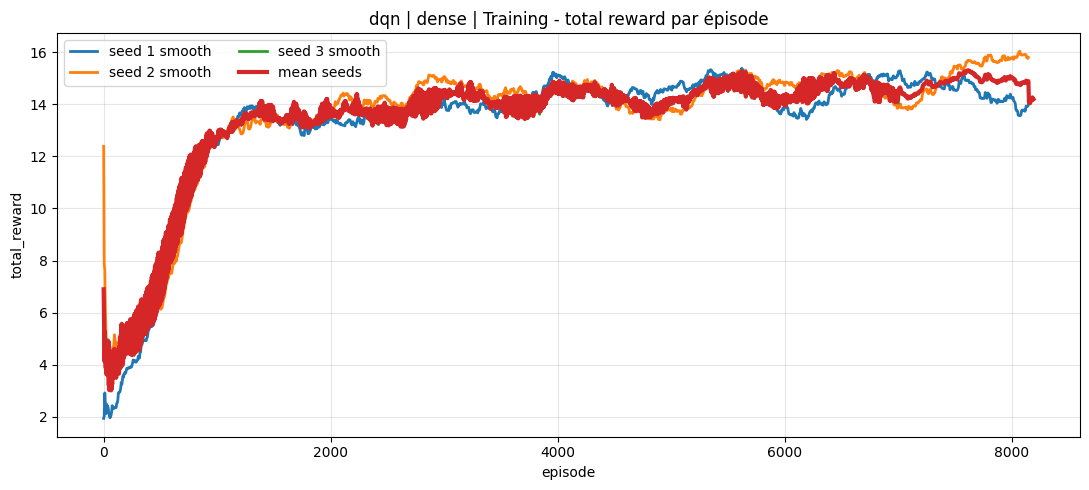

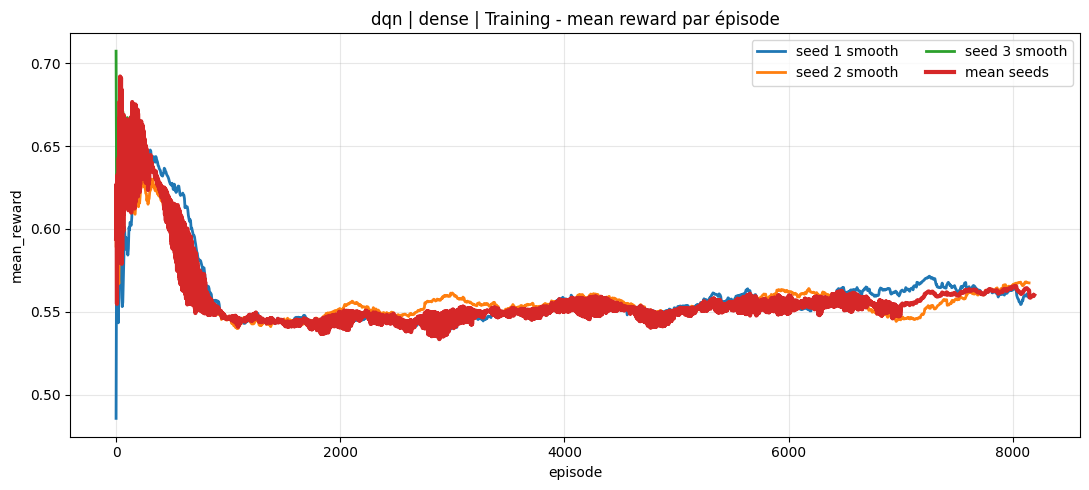

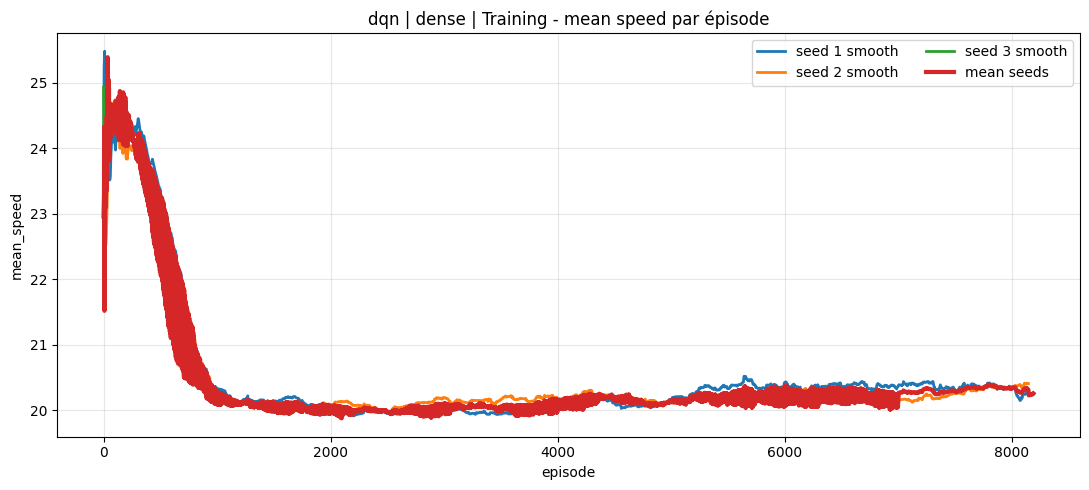

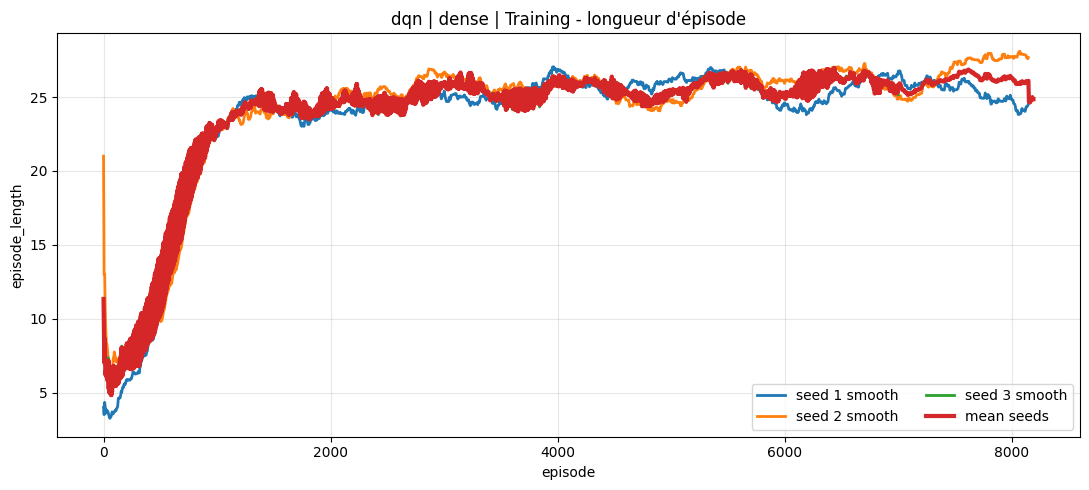

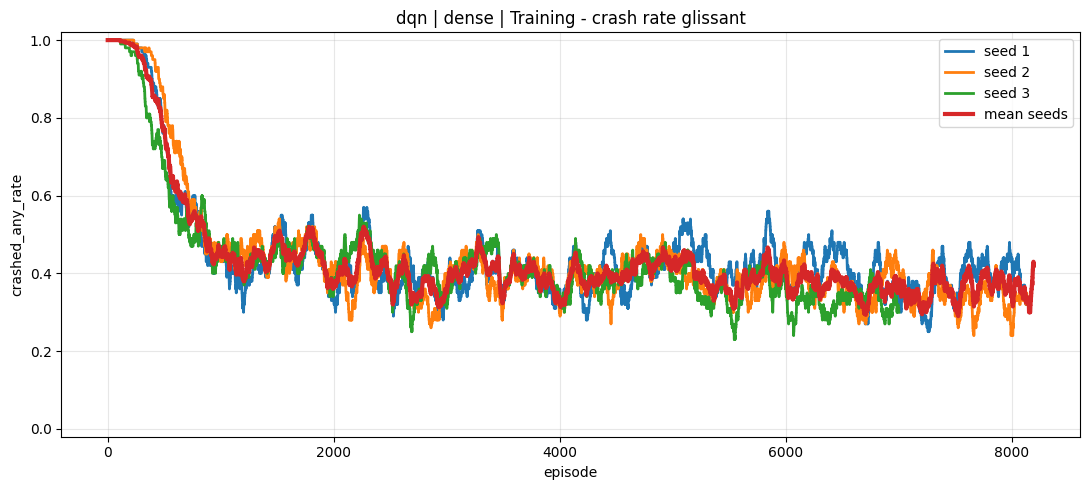

In [18]:
training_episode_histories = plot_all_training_graphs_for_model(
    base_dir=Path.cwd().parents[2],
    model_type=ModelType.DQN,
    env_type=EnvType.DENSE,
    seeds=SEEDS,
)

In [19]:
merged_eval_df, per_episode_stats, global_stats, per_seed_stats = display_evaluation_tables(
    base_dir=Path.cwd().parents[2],
    model_type=ModelType.DQN,
    env_type=EnvType.DENSE,
    seeds=SEEDS,
    round_digits=4,
)


=== EVALUATION GLOBAL STATS | dqn | dense ===
 reward_mean  reward_std  reward_min  reward_max  length_mean  length_std  length_min  length_max  mean_speed_mean  mean_speed_std  mean_speed_min  mean_speed_max  crash_rate  offroad_rate  n_rows  n_train_seeds
     20.4545         0.0     20.4545     20.4545         30.0         0.0          30          30          20.0344             0.0         20.0344         20.0344         0.0           0.0     150              3

=== EVALUATION PER TRAIN SEED | dqn | dense ===
 train_seed  n_rows  reward_mean  reward_std  reward_min  reward_max  length_mean  length_std  length_min  length_max  mean_speed_mean  mean_speed_std  mean_speed_min  mean_speed_max  crash_rate  offroad_rate
          1      50      20.4545         0.0     20.4545     20.4545         30.0         0.0          30          30          20.0344             0.0         20.0344         20.0344         0.0           0.0
          2      50      20.4545         0.0     20.4545     2

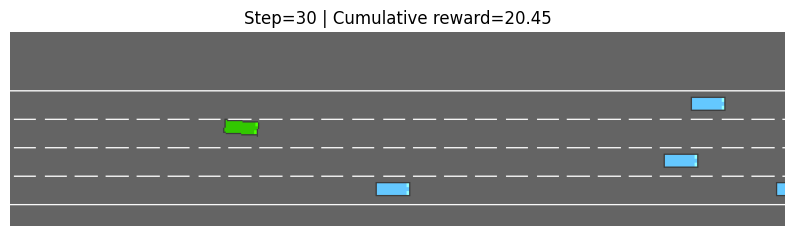

{'episode_reward': 20.454545454545464,
 'episode_length': 30,
 'crashed': False,
 'offroad': False,
 'mean_speed': 20.03435166840848}

In [20]:
env.reset(seed=seed)

model_type = ModelType.DQN
model_path = get_model_path(Path.cwd().parents[2], model_type, EnvType.DENSE, seed=1)
model = load_model(model_type, model_path)

stats = display_episode(
    env=env,
    model=model,
    greedy=True,
    sleep_time=0.03,
)
stats